# 03 · Carbon-aware scheduling vs a carbon-blind baseline

**Goal.** For each load type, compare a **carbon-blind** baseline against the
**carbon-minimising** schedule and report the carbon saved.

**Cost model.** Running a job at start hour $s$ for its `duration` hours costs

$$ \mathrm{cost}(s) \;=\; \text{power\_kw} \times \sum_{h=0}^{\text{dur}-1}\mathrm{CI}(s+h) $$

(kWh-weighted gCO2). The scheduler picks the cheapest feasible $s$ in each job's window.

- `fifo_baseline` — carbon-blind control: run every job at its `earliest_start`.
- `schedule` — greedy carbon-minimiser. **With no capacity cap the jobs never interact, so
  each takes its own cheapest hour: this is the exact per-job optimum**, identical to the
  MILP `schedule_optimal`.

Savings $= (\text{fifo} - \text{optimal}) / \text{fifo}$.

In [1]:
# --- standard setup for every notebook in this paper ------------------------
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, "..")                 # find cals (in ../)
from dotenv import load_dotenv; load_dotenv("../.env")  # loads EIA_API_KEY if present
from cals import *          # FACTORS, carbon_intensity, Job, schedule, fifo_baseline, ...
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import nb_utils as U             # guarded data loaders + figure helper (see notebooks/nb_utils.py)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [2]:
ci, source = U.get_carbon_intensity()
print("carbon source:", source)
hvac_jobs, run_hours, _ = U.load_hvac_jobs(flex_hours=6)
ev_jobs, ev_source = U.get_ev_jobs()
ai_jobs, ai_parsed, ai_source = U.get_ai_jobs(gpu_power_kw=0.4, flex_hours=6)
loads = {"HVAC": hvac_jobs, "EV": ev_jobs, "AI": ai_jobs}

carbon source: EIA ISO-NE (LIVE API)


EV: real ACN-Data unavailable (ModuleNotFoundError); using a labelled DEMO EV set. Install acnportal + set ACN_API_TOKEN for real sessions.


AI: real Alibaba GPU v2020 trace not found in data/ai/; using a labelled SYNTHETIC Alibaba-shaped trace.


## Per-load savings

Uncapacitated `schedule` == optimal, so the row below is the best any scheduler could do on
this carbon curve. (We also confirm greedy == the MILP `schedule_optimal` for HVAC.)

In [3]:
rows = []
for name, jobs in loads.items():
    fifo = fifo_baseline(jobs, ci)
    opt  = schedule(jobs, ci)                 # uncapacitated == optimal
    rows.append({"load": name, "jobs": len(jobs),
                 "fifo gCO2":    round(fifo["total_gco2"]),
                 "optimal gCO2": round(opt["total_gco2"]),
                 "savings %":    round(U.savings_pct(fifo["total_gco2"], opt["total_gco2"]), 2)})
table = pd.DataFrame(rows).set_index("load")
display(table)

# sanity check: greedy (uncapacitated) really is the exact optimum
g = schedule(hvac_jobs, ci)["total_gco2"]; m = schedule_optimal(hvac_jobs, ci)["total_gco2"]
print("HVAC greedy vs MILP optimal gCO2: %.1f vs %.1f  (equal => %s)" % (g, m, abs(g - m) < 1e-6))

,jobs,fifo gCO2,optimal gCO2,savings %
load,,,,
HVAC,8363,1219614,1082642,11.23
EV,200,1019546,977179,4.16
AI,299,415465,386482,6.98


HVAC greedy vs MILP optimal gCO2: 1082641.7 vs 1082641.7  (equal => True)


saved figure -> /project/painting/local-projects-to-run/carbon-aware-load-scheduling/code/figures/03_savings_by_load.png


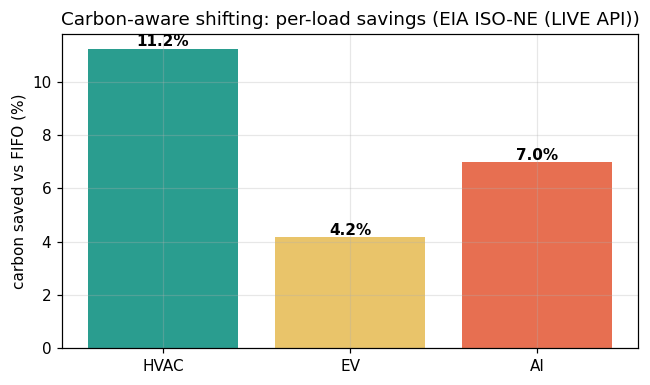

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(table.index, table["savings %"], color=["#2a9d8f", "#e9c46a", "#e76f51"])
for i, v in enumerate(table["savings %"]):
    ax.text(i, v + 0.1, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("carbon saved vs FIFO (%)")
ax.set_title(f"Carbon-aware shifting: per-load savings ({source})")
fig.tight_layout(); U.savefig(fig, "03_savings_by_load.png"); plt.show()

**Reading it.** Savings track two things: how much **slack** a load has (notebook 02) and
how much the CI curve **swings** inside that slack (notebook 01). HVAC's many small, flexible
hours across a whole year give it steady savings; EV/AI depend on their (demo) windows here.
Notebook 04 sweeps the knobs behind these numbers.